# Light-flavour Drell–Yan observable

This notebook compares a PineAPPL observable calculated using the `NNPDF_original` and `KDE_reconstruction` ensembles. It propagates the PDF uncertainty by calculating the observable with every Monte Carlo replica.

The reconstructed set contains $d$, $u$, $s$, $c$, their antiquarks and the gluon. The PineAPPL bottom and photon channels are excluded from both ensembles. 

Contributions outside the reconstruction x-grid are set to zero for both ensembles rather than extrapolated. 

In [13]:
import matplotlib.pyplot as plt
import numpy as np

from lhapdf_calc_observables import (
    ORIGINAL_SET_NAME,
    RECONSTRUCTED_SET_NAME,
    SCRIPT_DIR,
    ObservableStatistics,
    ObservablePlotStyle,
    PineAPPLObservable,
)

plot_style = ObservablePlotStyle()
plot_style.apply()
print(f"Using Matplotlib style: {plot_style.style_path}")

Using Matplotlib style: /Users/julieallen/Desktop/Emma/summerResearch2025/02_nnpdfDataCode/pythonStyle.mplstyle


### Load and inspect the PineAPPL grid

Load the grid, create the two-proton convolution and select the supported light-flavour channels.

In [14]:
observable = PineAPPLObservable()

observable.load()
print("Selected channels:", observable.supported_channels)
print("Bin limits:\n", observable.bin_limits())

Selected channels: (0, 1, 3, 5, 6, 8)
Bin limits:
 [[2.    2.125]
 [2.125 2.25 ]
 [2.25  2.375]
 [2.375 2.5  ]
 [2.5   2.625]
 [2.625 2.75 ]
 [2.75  2.875]
 [2.875 3.   ]
 [3.    3.125]
 [3.125 3.25 ]
 [3.25  3.375]
 [3.375 3.5  ]
 [3.5   3.625]
 [3.625 3.75 ]
 [3.75  3.875]
 [3.875 4.   ]
 [4.    4.25 ]
 [4.25  4.5  ]]


### Calculate the central predictions

Calculate the 18 observable bins using member 0 of each PDF set before running any replicas.

In [15]:
original_central = observable.calculate_member(ORIGINAL_SET_NAME, 0)
reconstructed_central = observable.calculate_member(RECONSTRUCTED_SET_NAME, 0)

print("Original central:\n", original_central)
print("Reconstructed central:\n", reconstructed_central)

Original central:
 [8.05304613e+00 2.36338048e+01 3.79410722e+01 5.08768944e+01
 6.19410250e+01 7.04180537e+01 7.60550184e+01 7.84108664e+01
 7.72667439e+01 7.23472285e+01 6.20987971e+01 4.85475035e+01
 3.48732179e+01 2.26095424e+01 1.29165289e+01 6.14355353e+00
 1.24309079e+00 2.69515375e-02]
Reconstructed central:
 [8.29345171e+00 2.44521598e+01 3.95013154e+01 5.31714582e+01
 6.50642717e+01 7.43458145e+01 8.07826215e+01 8.37589175e+01
 8.31570877e+01 7.84280258e+01 6.76602711e+01 5.32870526e+01
 3.84651351e+01 2.50966589e+01 1.44548807e+01 6.89553647e+00
 1.35912515e+00 1.80020583e-02]


### Test a small replica sample

Use 10 replicas from each ensemble to check the calculation and array shapes before running all 1,000 replicas. 

Replica indices start at 1 because member 0 is the central member.

In [16]:
test_members = range(1, 11)

original_test = observable.calculate_ensemble(ORIGINAL_SET_NAME, test_members)
reconstructed_test = observable.calculate_ensemble(
    RECONSTRUCTED_SET_NAME, test_members
)

print("Original test shape:", original_test.shape)
print("Reconstructed test shape:", reconstructed_test.shape)

Calculated 10/10 members from NNPDF_original
Calculated 10/10 members from KDE_reconstruction
Original test shape: (10, 18)
Reconstructed test shape: (10, 18)


### Propagate the full PDF uncertainties

Calculate the observable for all 1,000 replicas in each ensemble. 

The expected shape of each result is `(1000, 18)`.

In [17]:
all_replica_members = range(1, 1001)

original_replicas = observable.calculate_ensemble(
    ORIGINAL_SET_NAME, all_replica_members
)
reconstructed_replicas = observable.calculate_ensemble(
    RECONSTRUCTED_SET_NAME, all_replica_members
)

print("Original ensemble shape:", original_replicas.shape)
print("Reconstructed ensemble shape:", reconstructed_replicas.shape)

Calculated 100/1000 members from NNPDF_original
Calculated 200/1000 members from NNPDF_original
Calculated 300/1000 members from NNPDF_original
Calculated 400/1000 members from NNPDF_original
Calculated 500/1000 members from NNPDF_original
Calculated 600/1000 members from NNPDF_original
Calculated 700/1000 members from NNPDF_original
Calculated 800/1000 members from NNPDF_original
Calculated 900/1000 members from NNPDF_original
Calculated 1000/1000 members from NNPDF_original
Calculated 100/1000 members from KDE_reconstruction
Calculated 200/1000 members from KDE_reconstruction
Calculated 300/1000 members from KDE_reconstruction
Calculated 400/1000 members from KDE_reconstruction
Calculated 500/1000 members from KDE_reconstruction
Calculated 600/1000 members from KDE_reconstruction
Calculated 700/1000 members from KDE_reconstruction
Calculated 800/1000 members from KDE_reconstruction
Calculated 900/1000 members from KDE_reconstruction
Calculated 1000/1000 members from KDE_reconstructio

### Calculate ensemble statistics

Calculate the replica mean and sample standard deviation in every observable bin.

In [18]:
original_statistics = ObservableStatistics(original_replicas).summary()
reconstructed_statistics = ObservableStatistics(
    reconstructed_replicas
).summary()

print("Original standard deviation:\n", original_statistics["standard_deviation"])
print("Reconstructed standard deviation:\n", reconstructed_statistics["standard_deviation"])

Original standard deviation:
 [3.17919876e-02 9.70033359e-02 1.65208081e-01 2.38940176e-01
 3.10860427e-01 3.72370415e-01 4.17152722e-01 4.46731767e-01
 4.65162086e-01 4.65191703e-01 4.22969394e-01 3.52116649e-01
 2.84442828e-01 2.15670959e-01 1.47308575e-01 8.79053304e-02
 2.31773616e-02 4.53020988e-04]
Reconstructed standard deviation:
 [4.10040862e-01 1.17705723e+00 1.90091419e+00 2.85039643e+00
 4.04000395e+00 4.75820154e+00 5.93169769e+00 7.85236629e+00
 7.81409471e+00 9.79804585e+00 7.78832174e+00 6.84612066e+00
 6.56637995e+00 5.81680140e+00 4.27393615e+00 2.76167576e+00
 6.56774387e-01 9.39053323e-03]


### Plot predictions with uncertainty 

Plot the ensemble means and uncertainty intervals (plus, minus one standard deviation) for the original and reconstructed sets.

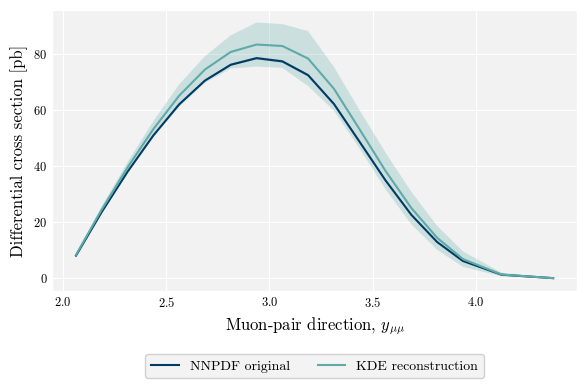

In [19]:
bin_centres = observable.bin_centres()

plot_style.apply()
fig, ax = plt.subplots()

original_line, = ax.plot(
    bin_centres, original_statistics["mean"],
    label=r"NNPDF original",
)
ax.fill_between(
    bin_centres,
    original_statistics["lower_standard_deviation"],
    original_statistics["upper_standard_deviation"],
    facecolor=original_line.get_color(), alpha=0.25,
)
reconstructed_line, = ax.plot(
    bin_centres, reconstructed_statistics["mean"],
    label=r"KDE reconstruction",
)
ax.fill_between(
    bin_centres,
    reconstructed_statistics["lower_standard_deviation"],
    reconstructed_statistics["upper_standard_deviation"],
    facecolor=reconstructed_line.get_color(), alpha=0.25,
)
ax.set_xlabel(r"Muon-pair direction, $y_{\mu\mu}$")
ax.set_ylabel(r"Differential cross section [pb]")
plot_style.add_legend(ax)
plot_style.save(fig, "prediction_uncertainties.png")
plt.show()